# Record The Data!

## Section 1: Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os, math, time, json, threading, queue, dataclasses
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, Future
from argparse import Namespace

import ctypes as ct
import numpy as np
import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageTk
import matplotlib
matplotlib.use("Agg")  # figures are rendered in worker threads and blitted onto Tk canvases -- never plt.*
from matplotlib.figure import Figure

import modal
import sounddevice as sd
import soundfile as sf
import cv2

# Add repo root and src/ to path -- same convention src/record.ipynb's own cell 3 uses, so
# `utils.*` and `data.*` resolve identically here.
REPO_DIR = Path.cwd().parent  # record.ipynb lives in record/, so its parent is the repo root
for p in (REPO_DIR, REPO_DIR / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
sys.path = [p for p in sys.path if p not in ("", str(Path.cwd()))]

from utils.ids_camera.pyueye_example_camera import Camera as _PyueyeCameraBase
from pyueye import ueye

try:
    from egrabber import *  # EGenTL, EGrabber, Buffer, BUFFER_INFO_* -- Mikrotron/CoaXPress SDK
except ImportError:
    print("egrabber not found, continuing without it (laser camera cells will fail).")

from record.utils import Task, log, Timing, logger
from record.utils.image import crop
from record.utils import geometry
from record.utils import viz
from record.utils.watcher import watch
from record.post_process import post_process as full_post_process, preview_vibrations
import record.segment as segment_mod
from data.audio import make_chirp, generate_chirp, main as generate_chirp_artifacts
from data.vibrate import warmup_pclk
from utils.io_utils import save, append, load, load_metadata

## Section 3: Overhead camera

In [3]:
@dataclass
class OverheadCameraConfig:
    device_id: int = 0
    exposure_bounds_ms: tuple[float, float] = (0.1, 100.0)
    gain_bounds: tuple[int, int] = (0, 100)
    pixel_clock_bounds: tuple[int, int] = (20, 150)
    exposure_ms: float = 12.0
    frame_rate: float = 30.0
    pixel_clock: int = 86
    gain: int = 1
    hand_delay: float = 0.1  # seconds to wait after positioning the overhead shot, so a hand isn't in frame

overhead_camera_config = OverheadCameraConfig()
overhead_camera_config

OverheadCameraConfig(device_id=0, exposure_bounds_ms=(0.1, 100.0), gain_bounds=(0, 100), pixel_clock_bounds=(20, 150), exposure_ms=12.0, frame_rate=30.0, pixel_clock=86, gain=1, hand_delay=0.1)

In [4]:
class PyueyeCamera:
    # Thin wrapper around utils.ids_camera.pyueye_example_camera.Camera (already used by
    # both src/record.ipynb and matan_main_capture.ipynb) -- init/alloc/colormode/initial
    # settings happen here; start()/end() toggle streaming explicitly (symmetric with
    # MikrotronCamera below, which genuinely needs this); one capture method serves both
    # the always-on live-preview tick and the once-per-position official capture.
    def __init__(self, config: OverheadCameraConfig):
        self.config = config
        self._cam = _PyueyeCameraBase(device_id=config.device_id)
        self._cam.init()
        self._cam.set_colormode(ueye.IS_CM_SENSOR_RAW8)
        self._cam.alloc(buffer_count=40)
        self._cam.set_pixel_clock(config.pixel_clock)
        self._cam.set_exposure(config.exposure_ms)
        self._cam.set_gain(config.gain)
        self._frame_rate = self._cam.set_frame_rate(config.frame_rate)
        aoi = self._cam.get_aoi()
        self.width, self.height = aoi.width, aoi.height

    def start(self):
        self._cam.disable_external_trigger()
        self._cam.capture_video()

    def end(self):
        self._cam.stop_video()

    def close(self):
        # Releases the uEye device handle (is_ExitCamera) -- distinct from end(), which only
        # stops streaming. Without this, constructing a second PyueyeCamera for the same
        # device_id (e.g. re-running the smoke-test cell below) fails with uEyeException:
        # Err 213 (IS_DEVICE_IN_USE), since the first handle is still open.
        self._cam.exit()

    def get_exposure(self): return self._cam.get_exposure()
    def set_exposure(self, exposure_ms): self._cam.set_exposure(exposure_ms)
    def get_gain(self): return self._cam.get_gain()
    def set_gain(self, gain): self._cam.set_gain(gain)
    def get_pixel_clock(self): return self._cam.get_pixel_clock()
    def set_pixel_clock(self, pixel_clock): self._cam.set_pixel_clock(pixel_clock)
    def get_frame_rate(self): return self._frame_rate
    def set_frame_rate(self, frame_rate):
        self._frame_rate = self._cam.set_frame_rate(frame_rate)
        return self._frame_rate

    def capture_overhead(self) -> np.ndarray:
        # valid only while started (a live-preview tick calls this with n=1 implicitly --
        # it just reads whatever frame is ready -- and a real position capture calls it once)
        raw_frame, _ = self._cam.read_frame()
        color = cv2.cvtColor(raw_frame.astype("uint8"), cv2.COLOR_BAYER_BG2RGB)
        color = cv2.rotate(color, cv2.ROTATE_180)
        return color

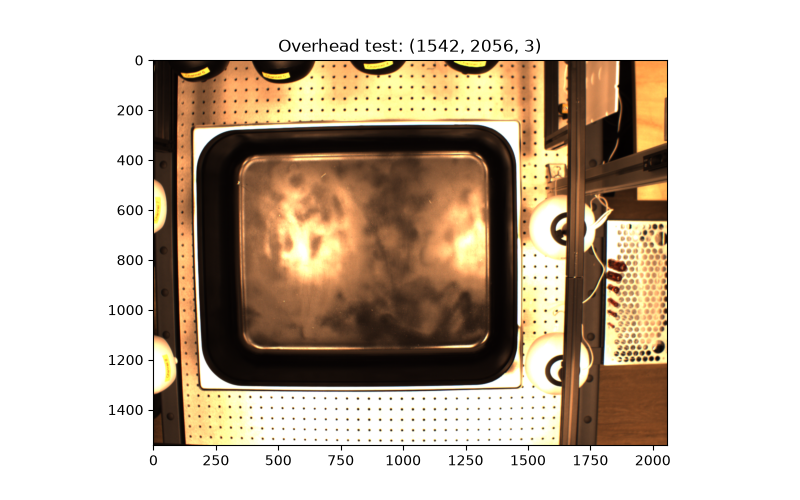

In [7]:
# safe to re-run: close() releases the uEye device handle a previous run of this cell
# left open (see PyueyeCamera.close() above) before opening a fresh one
if "overhead_cam" in globals():
    overhead_cam.close()
overhead_cam = PyueyeCamera(overhead_camera_config)
overhead_cam.start()
_overhead_smoke_frame = overhead_cam.capture_overhead()
overhead_cam.end()

_fig = Figure(figsize=(8, 5))
_ax = _fig.subplots()
_ax.imshow(_overhead_smoke_frame)
_ax.set_title(f"Overhead test: {_overhead_smoke_frame.shape}")
Image.fromarray(viz.figure_to_array(_fig))

## Section 4: Laser camera

In [9]:
@dataclass
class ROIConfig:
    n_rows: int = 10
    n_cols: int = 10
    roi_width: int = 40   # column width, px
    roi_height: int = 30  # row height, px -- independently tunable from roi_width (ports
                           # record.ipynb's separate ROI_ROW_HEIGHT=30 vs ROI_COLUMN_WIDTH=40)
    rois: list[tuple[int, int, int, int]] | None = None  # (x, y, w, h) per ROI, row-major;
                                                          # None for the wide-open calibration config

default_roi = ROIConfig()
default_roi

ROIConfig(n_rows=10, n_cols=10, roi_width=40, roi_height=30, rois=None)

In [10]:
@dataclass
class LaserCameraConfig:
    exposure_bounds_us: tuple[float, float] = (1.0, 2000.0)
    gain_bounds: tuple[float, float] = (0.0, 24.0)
    roi: ROIConfig = field(default_factory=lambda: default_roi)
    buffer_part_count: int = 1625  # 1 for the temporary wide-open calibration config
    exposure_us: float = 90.0
    gain: float = 1.0

laser_camera_config = LaserCameraConfig(roi=default_roi)
laser_camera_config

LaserCameraConfig(exposure_bounds_us=(1.0, 2000.0), gain_bounds=(0.0, 24.0), roi=ROIConfig(n_rows=10, n_cols=10, roi_width=40, roi_height=30, rois=None), buffer_part_count=1625, exposure_us=90.0, gain=1.0)

In [11]:
class MikrotronCamera:
    def __init__(self, config: LaserCameraConfig):
        self.config = config
        self._gentl = EGenTL()
        self.grabber = EGrabber(self._gentl)
        self.grabber.stream.set("BufferPartCount", 1)
        self._update_size()
        self.grabber.realloc_buffers(20)

        self.set_exposure(config.exposure_us)
        self.set_gain(config.gain)

        if config.roi.rois is None:
            self.reset_global_roi()  # wide-open: full sensor, for click-calibration
        else:
            self._apply_roi_grid(config.roi)

        self.set_buffer_part_count(config.buffer_part_count)

    # ---- lifecycle ----
    def start(self):
        self.grabber.flush_buffers()
        self.grabber.start()

    def end(self):
        self.grabber.stop()
        self.grabber.flush_buffers()

    # ---- get/set ----
    def get_exposure(self): return self.grabber.remote.get("ExposureTime")
    def set_exposure(self, exposure_us): self.grabber.remote.set("ExposureTime", exposure_us)
    def get_gain(self): return self.grabber.remote.get("Gain")
    def set_gain(self, gain): self.grabber.remote.set("Gain", gain)
    def get_frame_rate(self): return self.grabber.remote.get("AcquisitionFrameRate")
    def set_frame_rate(self, frame_rate): self.grabber.remote.set("AcquisitionFrameRate", frame_rate)
    def get_max_frame_rate(self): return self.grabber.remote.get("AcquisitionFrameRateMax")

    def set_buffer_part_count(self, buffer_part_count):
        self.grabber.stop()
        self.grabber.stream.set("BufferPartCount", buffer_part_count)
        self.grabber.realloc_buffers(20)
        self.config.buffer_part_count = buffer_part_count

    def get_global_roi(self):
        x = self.grabber.remote.get("OffsetX")
        w = self.grabber.remote.get("Width")
        y = self.grabber.remote.get("OffsetY")
        h = self.grabber.remote.get("Height")
        return (x, y, w, h)

    # ---- internals (ported verbatim from src/record.ipynb cell 21) ----
    def _update_size(self):
        self.width = self.grabber.stream.get("Width")
        self.height = self.grabber.stream.get("Height")

    def _reset_buffer(self):
        self._update_size()
        self.grabber.stop()
        self.grabber.realloc_buffers(20)
        self.grabber.start()

    def reset_global_roi(self):
        self.grabber.stop()
        self.grabber.remote.set("MultiROILUTModeEn", False)
        self.grabber.remote.set("OffsetX", 0)
        self.grabber.remote.set("OffsetY", 0)
        self.grabber.remote.set("Width", 1920)
        self.grabber.remote.set("Height", 1080)
        self._reset_buffer()

    def set_global_roi_noy(self, x, y, w, h):
        if w < 128 or w % 16 != 0 or w > 1920:
            raise ValueError("Width must be > 128px and a multiple of 16")
        if x % 16 != 0:
            raise ValueError("OffsetX must be a multiple of 16")
        # this order matters: set height to a smaller value first, then it lets you set the offset
        self.grabber.remote.set("Width", w)
        self.grabber.remote.set("Height", h)
        self.grabber.remote.set("OffsetX", x)
        self._reset_buffer()

    def set_rows(self, row_idxs):
        self.grabber.remote.set("MultiROILUTModeEn", False)
        H = len(row_idxs) * 2
        if H % 4 != 0:
            raise ValueError("row count must produce a height that's a multiple of 4")
        for i, idx in enumerate(row_idxs):
            self.grabber.remote.set("MultiROILUTIndex", i)
            self.grabber.remote.set("MultiROILUTValue", int(idx))
        self.grabber.remote.set("Height", H)
        self.grabber.remote.set("MultiROILUTModeEn", True)
        self._reset_buffer()

    def _apply_roi_grid(self, roi: ROIConfig):
        # global (horizontal) crop, 16px-aligned, derived from the ROI x-extents
        xs = [x for x, y, w, h in roi.rois]
        x_ends = [x + w for x, y, w, h in roi.rois]
        offset_x = int(round(min(xs) / 16) * 16)
        width = int(round((max(x_ends) - offset_x) / 16) * 16)
        total_height = roi.n_rows * roi.roi_height
        self.set_global_roi_noy(offset_x, 0, width, total_height)
        # one row-register per 2px-quantized row, per set_rows()'s hardware requirement
        row_idxs = []
        for row in range(roi.n_rows):
            y0 = row * roi.roi_height
            row_idxs.extend((np.arange(y0, y0 + roi.roi_height, 2) // 2).tolist())
        self.set_rows(row_idxs)

    # ---- capture (ported from CaptureFrameThread2, de-threaded -- see class docstring) ----
    def capture_vibrations(self, n_frames: int) -> np.ndarray:
        # exact port of CaptureFrameThread2's buffer math -- stream.Height (not derived
        # here) is what a real capture's buffer array is allocated against; do not "clean
        # this up" without hardware to verify against, see class docstring.
        frames_per_buffer = self.grabber.stream.get("BufferPartCount")
        n_buffers = int(np.ceil(n_frames / frames_per_buffer))
        w = self.grabber.stream.get("Width")
        h = self.grabber.stream.get("Height")
        h_roi = self.get_global_roi()[-1]
        frames = np.empty((n_buffers, h, w), dtype=np.uint8)
        for i in range(n_buffers):
            with Buffer(self.grabber, timeout=5000) as buffer:
                buffer_ptr = buffer.get_info(BUFFER_INFO_BASE, INFO_DATATYPE_PTR)
                image_size = buffer.get_info(BUFFER_INFO_CUSTOM_PART_SIZE, INFO_DATATYPE_SIZET)
                delivered = buffer.get_info(BUFFER_INFO_CUSTOM_NUM_DELIVERED_PARTS, INFO_DATATYPE_SIZET)
                proc = 0
                while proc < delivered:
                    part_ptr = buffer_ptr + proc * image_size
                    data = ct.cast(part_ptr, ct.POINTER(ct.c_ubyte * image_size)).contents
                    img = np.frombuffer(data, count=image_size, dtype=np.uint8).reshape((-1, w))
                    frames[i, proc * h_roi:(proc + 1) * h_roi] = img.copy()
                    proc += 1
        video = frames.reshape(n_buffers * frames_per_buffer, h_roi, w)
        return video[:n_frames]

In [14]:
laser_cam = MikrotronCamera(laser_camera_config)
laser_cam.start()
_laser_smoke_frame = laser_cam.capture_vibrations(n_frames=1)[0]
laser_cam.end()

_fig = Figure(figsize=(8, 3))
_ax = _fig.subplots()
_ax.imshow(_laser_smoke_frame, cmap="gray")
_ax.set_title(f"Laser smoke test: {_laser_smoke_frame.shape}")
Image.fromarray(viz.figure_to_array(_fig))

ResourceInUseException: GCInitLib: Requested resource is already in use

## Section 5: Audio engine

In [ ]:
def _find_output_device(name_substring: str, hostapi_name: str = "Windows WASAPI") -> int:
    hostapis = sd.query_hostapis()
    target_hostapi = next(i for i, h in enumerate(hostapis) if h["name"] == hostapi_name)
    for idx, dev in enumerate(sd.query_devices()):
        if dev["hostapi"] == target_hostapi and name_substring in dev["name"] and dev["max_output_channels"] > 0:
            return idx
    raise ValueError(f"No output device matching {name_substring!r}")


def _as_audio(a) -> np.ndarray:
    if isinstance(a, (str, Path)):
        return sf.read(str(a), dtype="float32", always_2d=True)[0].mean(1)
    a = np.asarray(a, np.float32)
    return a.mean(1) if a.ndim > 1 else a


@dataclass
class AudioConfig:
    # speaker id -> (device name substring, (channel index, mono)) -- ports record.ipynb
    # cell 58's SPEAKERS dict, split into the two fields each Config carries
    speaker_device_names: dict = field(default_factory=lambda: {
        1: "Main Out 1-2", 2: "Main Out 1-2", 3: "Line Out 3-4", 4: "Line Out 3-4",
        5: "Line Out 5-6", 6: "Line Out 5-6", 7: "Line Out 7-8", 8: "Line Out 7-8",
    })
    speaker_channels: dict = field(default_factory=lambda: {
        1: (0, False), 2: (1, False), 3: (1, False), 4: (0, False),
        5: (0, False), 6: (1, False), 7: (0, False), 8: (1, False),
    })
    sample_rate: int = 0  # 0 = auto-detect from the first resolved device at construction
    settle_seconds: float = 0.25  # WASAPI shared-mode output latency guard (data/vibrate.py's AUDIO_SETTLE_SECONDS)
    speaker_delay: float = 0.1  # seconds between speakers, so they don't interfere with each other

audio_config = AudioConfig()
audio_config

In [ ]:
class AudioEngine:
    # One persistent sd.OutputStream per physical device, opened once; play() is
    # non-blocking (spawns a Task per device sharing this call's speakers, ports
    # record.ipynb cell 60's play_audio/feed design unchanged).
    def __init__(self, config: AudioConfig):
        self.config = config
        unique_names = sorted(set(config.speaker_device_names.values()))
        self._device_index = {name: _find_output_device(name) for name in unique_names}
        self._devices = sorted(set(self._device_index.values()))
        self.sample_rate = config.sample_rate or int(sd.query_devices(self._devices[0])["default_samplerate"])
        self._locks = {d: threading.Lock() for d in self._devices}
        self._streams = {}
        self._open_streams()

    def _open_streams(self):
        for d in self._devices:
            self._streams[d] = sd.OutputStream(samplerate=self.sample_rate, device=d, channels=2, blocksize=1024)
            self._streams[d].start()

    def close(self):
        for s in self._streams.values():
            try:
                s.abort(); s.close()
            except Exception:
                pass
        self._streams.clear()

    def reset(self):
        # ports record.ipynb's open_audio()/close_audio() crash-recovery idiom (there,
        # called unconditionally at the top of every position); here, called only from
        # run_experiment's exception handler (§1.4) since the engine is opened once for
        # the whole session, not once per position.
        self.close()
        self._open_streams()

    def _feed(self, device, buf):
        dur = len(buf) / self.sample_rate
        with self._locks[device]:
            t0 = time.perf_counter()
            self._streams[device].write(buf)
            time.sleep(max(0, dur - (time.perf_counter() - t0)))

    def play(self, audio, speakers):
        audio = _as_audio(audio)
        speakers = speakers if isinstance(speakers, (list, tuple)) else [speakers]
        per_device = {}
        for spk in speakers:
            device = self._device_index[self.config.speaker_device_names[spk]]
            channel, mono = self.config.speaker_channels[spk]
            per_device.setdefault(device, np.zeros((len(audio), 2), np.float32))
            if mono:
                per_device[device][:, 0] = per_device[device][:, 1] = audio
            else:
                per_device[device][:, channel] = audio
        for device, buf in per_device.items():
            Task(self._feed, device, buf)

In [ ]:
# Smoke test: confirms devices were found and the stream opens, with defaults.
audio_engine = AudioEngine(audio_config)
_test_tone = (0.2 * np.sin(2 * np.pi * 440 * np.arange(int(audio_engine.sample_rate * 0.3)) / audio_engine.sample_rate)).astype(np.float32)
audio_engine.play(_test_tone, speakers=[1])

## Section 6: Chirp / audio signal

In [ ]:
@dataclass
class ChirpConfig:
    t_sec: float = 1.0
    t_start: float = 0.1
    t_end: float = 0.1
    fs: int = 44100
    f_start: float = 100.0
    f_end: float = 1000.0

chirp_config = ChirpConfig()
chirp_config

In [ ]:
# Generates (or loads, if already generated for these exact chirp params -- data.audio.main
# is idempotent, caching under data/audio/chirp_{f_start}_{f_end}_{t_sec}sec/) the chirp WAV,
# plus the fixed "done" whistle. chirp_samples/done_whistle_samples feed run_experiment later.
_chirp_args = Namespace(T_sec=chirp_config.t_sec, T_start=chirp_config.t_start, T_end=chirp_config.t_end,
                        fs=chirp_config.fs, f_start=chirp_config.f_start, f_end=chirp_config.f_end, out_dir=None)
chirp_samples = generate_chirp_artifacts(_chirp_args)
done_whistle_samples = _as_audio(REPO_DIR / "data" / "whatsapp-whistle.mp3")

## Section 7: Session setup

In [ ]:
# Set this per recording session.
experiment_dir = Path(r"D:/eturok/experiment_name")
experiment_dir

In [ ]:
@dataclass
class CropConfig:
    # Fractions of width/height in [0.0, 1.0], image-array convention (origin top-left, y
    # increasing downward) -- matches crop()'s untouched implementation (record/utils/image.py,
    # ported from src/record.ipynb cell 67). left=0, right=1, top=0, bottom=1 = full image
    # (no crop) -- NOT all-zero, which would slice to an empty image.
    left: float = 0.0
    right: float = 1.0
    top: float = 0.0
    bottom: float = 1.0


@dataclass
class BoxConfig:
    name: str
    crop_params: CropConfig


BOXES = {name: BoxConfig(name, CropConfig(**params)) for name, params in {
    "taped-cardboard": dict(left=0.07, right=0.63, top=0.05, bottom=0.65),
    "slat-wood":       dict(left=0.2,  right=0.55, top=0.2,  bottom=0.8),
    "metal":           dict(left=0.21, right=0.54, top=0.66, bottom=0.86),
    "plastic":         dict(left=0.24, right=0.59, top=0.27, bottom=0.62),
    "gastronorm":      dict(left=0.05, right=0.7,  top=0.1,  bottom=0.82),
    "green-plastic":   dict(left=0.07, right=0.75, top=0.01, bottom=0.82),
    "wood":            dict(left=0.14, right=0.64, top=0.0001, bottom=0.7),
    "cardboard":       dict(left=0.15, right=0.6,  top=0.1,  bottom=0.93),
    "shoebox":         dict(left=0.17, right=0.56, top=0.4,  bottom=0.84),
}.items()}

PROMPTS = {
    "bullet": "Metal circle", "cylinder-bullet-stack": "Metal circle",
    "green-cube": "Green square", "purple-cube": "Purple square", "red-cube": "Red cube",
    "left shoe": "white sneaker", "right shoe": "white sneaker", "pingpong paddle": "pingpong paddle",
    "dog toy": "dog toy", "mug": "inside of the mug", "candle": "candle",
    "soap dispenser": "a white rectangle soap dispenser", "tomato sauce": "tomato sauce can",
    "coffee pot": "moka coffee pot", "plant": "circular plant and pot", "biscoff": "red lid",
    "coffee can": "coffee container", "cube": "red square", "vase": "tan circular ceramic vase",
    "cylinder": "silver metal cylinder", "ring": "gray concrete ring",
    "cylinder-500g": "silver metal cylinder", "cylinder-200g": "silver metal cylinder",
    "cylinder-100g": "silver metal cylinder", "glass-cup": "glass cup",
    "duct-tape": "roll of duct tape", "book": "book", "red-beans": "bag of red beans", "quinoa": "bag of red quinoa",
}

# (x_frac, y_frac) of the box area, NOTE: y=0 at the BOTTOM -- Cartesian, a deliberately
# different convention from CropConfig above. Ported verbatim from viz/config.py's
# SPEAKER_POSITION (itself copied from src/data/image.py's draw_speaker, which flips it via
# int((1 - y_frac) * H) when drawing -- the overhead panel's speaker-lit-up overlay does the
# same, §ection 11).
SPEAKER_POSITION = {1: (1, 0), 2: (1, 0.7), 3: (0.8, 1), 4: (0.6, 1), 5: (0.4, 1), 6: (0.2, 1), 7: (0, 0.7), 8: (0, 0)}

In [ ]:
@dataclass
class PositionConfig:
    speakers: list = field(default_factory=lambda: [1, 3, 5, 7])
    box: BoxConfig = field(default_factory=lambda: BOXES["gastronorm"])
    objects: dict = field(default_factory=dict)  # object name -> expected instance count
    layout: str = "empty-box"
    description: str = "An empty gastronorm box from a bird's eye view."

position_config = PositionConfig()
position_config

In [ ]:
@dataclass
class PreviewConfig:
    speaker: int = 1
    laser: int = 55
    use_pc: bool = True

preview_config = PreviewConfig()
preview_config

## Section 8: Pipeline state

`ExperimentConfig` holds *only* pipeline data -- no Tk widgets/canvases -- so every function in Section 9 below is testable without any GUI: they only ever take `experiment_config` + plain data.

In [ ]:
def _count_sample_dirs(path: Path) -> int:
    # ports record.ipynb's count_dirs() -- seeds the in-memory sample-id counter once, at
    # startup; never rescanned mid-session (§1.4).
    return 1 + (sum(1 for p in path.iterdir() if p.is_dir()) if path.exists() else 0)


def _next_position_id(positions_file: Path) -> int:
    # ports record.ipynb's get_position_id() -- seeds the in-memory position-id counter once.
    lines = positions_file.read_text().splitlines() if positions_file.exists() else []
    return max((int(k) for ln in lines for k in json.loads(ln)), default=0) + 1


class ExperimentConfig:
    def __init__(self, experiment_dir, overhead_cam, laser_cam, audio_engine, chirp_samples,
                 done_whistle_samples, preview_config, prompts, speaker_position, segmenter):
        self.experiment_dir = Path(experiment_dir)
        (self.experiment_dir / "samples").mkdir(parents=True, exist_ok=True)
        (self.experiment_dir / "positions.jsonl").touch(exist_ok=True)

        self.overhead_cam = overhead_cam
        self.laser_cam = laser_cam
        self.audio_engine = audio_engine
        self.chirp_samples = chirp_samples
        self.done_whistle_samples = done_whistle_samples
        self.preview_config = preview_config
        self.prompts = prompts
        self.speaker_position = speaker_position
        self.segmenter = segmenter

        # mutable session state
        self._id_lock = threading.Lock()
        self.next_sample_id = _count_sample_dirs(self.experiment_dir / "samples")
        self.next_position_id = _next_position_id(self.experiment_dir / "positions.jsonl")
        self.coverage = {}  # layout -> {"mask": np.ndarray, "n_samples": int}
        self._load_existing_coverage()
        self.stop_event = threading.Event()
        self.raw_save_pool = ThreadPoolExecutor(max_workers=2)  # bounds concurrent SAVE_RAW_VIBRATION writes (§1.4)
        self.log_queue = queue.Queue()
        self.tasks = {}  # panel name ('smask'/'coverage'/'shifts'/'freqs') -> most recent Task
        self.panel_queues = {name: queue.Queue() for name in ("smask", "coverage", "shifts", "freqs")}

    def _load_existing_coverage(self):
        samples_dir = self.experiment_dir / "samples"
        if not samples_dir.exists():
            return
        for sample_dir in sorted(samples_dir.iterdir()):
            metadata_path, smask_path = sample_dir / "metadata.jsonl", sample_dir / "image/03_smask.npy"
            if not (metadata_path.exists() and smask_path.exists()):
                continue
            layout = load_metadata(metadata_path).get("layout")
            if layout is None:
                continue
            smask = load(smask_path)
            entry = self.coverage.get(layout)
            if entry is not None and entry["mask"].shape != smask.shape:
                entry = None  # shape guard (§ Section 9) -- crop is GUI-editable, so this can genuinely happen
            if entry is None:
                entry = {"mask": np.zeros(smask.shape, dtype=np.float64), "n_samples": 0}
            entry["mask"] = entry["mask"] + smask
            entry["n_samples"] += 1
            self.coverage[layout] = entry

In [ ]:
experiment_config = ExperimentConfig(
    experiment_dir=experiment_dir, overhead_cam=overhead_cam, laser_cam=laser_cam,
    audio_engine=audio_engine, chirp_samples=chirp_samples, done_whistle_samples=done_whistle_samples,
    preview_config=preview_config, prompts=PROMPTS, speaker_position=SPEAKER_POSITION,
    segmenter=segment_mod.get_segmenter(),
)
experiment_config

## Section 9: Capture pipeline

GUI-independent orchestration. Lifecycle messages always fire via `log(ec, msg)` (prints *and* queues for the GUI, §2); `verbose` only gates internal diagnostic `Timing(...)` blocks -- it's not a second status channel.

In [ ]:
def save_raw_vibration(experiment_config, sample_dir: Path, raw_vibrations: np.ndarray):
    ec = experiment_config
    save(raw_vibrations, sample_dir / "vibration/01_raw_vibrations.npy")
    append({"save_vibrations": datetime.now(timezone.utc).isoformat()}, sample_dir / "times.jsonl")
    # Minimal metadata.jsonl seed (fps + rois), written HERE rather than in save_sample, so
    # post_process's file-triggered full save (which only needs fps/rois) never has to wait
    # on segmentation finishing -- it can lag behind save_raw_vibration by however long Modal
    # takes (§1.5).
    append({"fps": ec.laser_cam.get_frame_rate(), "rois": ec.laser_cam.config.roi.rois}, sample_dir / "metadata.jsonl")
    full_post_process.submit(sample_dir)

In [ ]:
def plot_smask(experiment_config, seg_task, crop_overhead, object_names):
    seg_task.join()
    if seg_task.exception is not None:
        log(experiment_config, f"plot_smask: SEGMENT failed: {seg_task.exception!r}")
        return
    fig = Figure(figsize=(6, 5))
    ax = fig.subplots()
    viz.draw_smask(ax, seg_task.result, crop_overhead, object_names)
    experiment_config.panel_queues["smask"].put(viz.figure_to_array(fig))


def plot_coverage(experiment_config, save_task, sample_dir):
    save_task.join()
    if save_task.exception is not None:
        log(experiment_config, f"plot_coverage: SAVE_SAMPLE failed: {save_task.exception!r}")
        return
    layout = load_metadata(sample_dir / "metadata.jsonl")["layout"]
    entry = experiment_config.coverage.get(layout)
    if entry is None:
        return
    fig = Figure(figsize=(6, 5))
    ax = fig.subplots()
    viz.draw_coverage(ax, entry["mask"], entry["n_samples"], layout)
    experiment_config.panel_queues["coverage"].put(viz.figure_to_array(fig))


def plot_shifts(experiment_config, pclk_task):
    pclk_task.join()
    if pclk_task.exception is not None:
        log(experiment_config, f"plot_shifts: pclk failed: {pclk_task.exception!r}")
        return
    result = pclk_task.result
    fig = Figure(figsize=(6, 3))
    ax = fig.subplots()
    viz.draw_shifts(ax, result["shifts"], experiment_config.laser_cam.get_frame_rate(), result["laser_idx"])
    experiment_config.panel_queues["shifts"].put(viz.figure_to_array(fig))


def plot_freqs(experiment_config, pclk_task):
    # no separate use_pc param needed here -- pclk_task already applied that choice when it
    # computed fft/freqs; this function only renders what's already in .result
    pclk_task.join()
    if pclk_task.exception is not None:
        log(experiment_config, f"plot_freqs: pclk failed: {pclk_task.exception!r}")
        return
    result = pclk_task.result
    fig = Figure(figsize=(6, 3))
    ax = fig.subplots()
    viz.draw_freqs(ax, result["fft"], result["freqs"], result["laser_idx"])
    experiment_config.panel_queues["freqs"].put(viz.figure_to_array(fig))

In [ ]:
def save_sample(experiment_config, speaker, sample_dir: Path, seg_task, save_vibration_future,
                 position, position_id, raw_overhead, crop_overhead):
    ec = experiment_config
    seg_task.join()
    seg_results = seg_task.result if seg_task.exception is None else []
    if seg_task.exception is not None:
        log(ec, f"save_sample: SEGMENT failed: {seg_task.exception!r}")
    save_vibration_future.result()  # Future.result() blocks + re-raises if save_raw_vibration failed

    object_names = list(position.objects)
    coms = segment_mod.object_centers_of_mass(seg_results)
    avg_com = np.mean([c for r in coms for c in r], axis=0).tolist() if any(coms) else []
    smask = segment_mod.combined_smask(seg_results, crop_overhead.shape[:2])

    sample_id = sample_dir.name
    sample_dir.mkdir(parents=True, exist_ok=True)

    id_params = dict(sample_id=sample_id, position_id=position_id, speaker=speaker,
                      experiment_dir=str(ec.experiment_dir), timestamp=datetime.now(timezone.utc).isoformat())
    object_params = dict(box=position.box.name, n_objects=sum(position.objects.values()),
                          objects=position.objects, layout=position.layout, description=position.description,
                          is_empty_box=len(position.objects) == 0)
    segment_params = dict(prompts=ec.prompts, coms=coms, avg_com=avg_com)
    append([id_params, object_params, segment_params], sample_dir / "metadata.jsonl")

    save(raw_overhead, sample_dir / "image/01_raw_overhead.png")
    save(crop_overhead, sample_dir / "image/02_cropped_overhead.png")
    save(smask, sample_dir / "image/03_smask.npy")
    save(smask, sample_dir / "image/03_smask.png")
    for (obj_name, _), r in zip(position.objects.items(), seg_results):
        for j, m in enumerate(r["masks"]):
            save(m, sample_dir / f"image/smasks/{obj_name}{j}.npy")

    # coverage, with the shape guard ported from record.ipynb (more likely to trigger now
    # that CropConfig is GUI-editable than when box was one of a few hardcoded presets)
    layout = position.layout
    entry = ec.coverage.get(layout)
    if entry is not None and entry["mask"].shape != smask.shape:
        entry = None
    if entry is None:
        entry = {"mask": np.zeros(smask.shape, dtype=np.float64), "n_samples": 0}
    entry["mask"] = entry["mask"] + smask
    entry["n_samples"] += 1
    ec.coverage[layout] = entry

In [ ]:
def run_experiment(experiment_config, position, save=True, vibrate=True, verbose=True):
    ec = experiment_config

    # reserve ids -- in-memory counters, lock-guarded since overlapping positions can call
    # this concurrently (Record re-enables before this position's background work finishes)
    with ec._id_lock:
        position_id = ec.next_position_id; ec.next_position_id += 1
        n0 = ec.next_sample_id; ec.next_sample_id += len(position.speakers)
    sample_dirs = [ec.experiment_dir / "samples" / f"{n0 + k:06d}" for k in range(len(position.speakers))]

    t0 = time.perf_counter()
    log(ec, f"Recording Position {position_id} with speakers {position.speakers} "
            f"(samples [{sample_dirs[0].name}, {sample_dirs[-1].name}])")

    # --- overhead: once per position ---
    with Timing("capture_overhead: ", enabled=verbose):
        time.sleep(ec.overhead_cam.config.hand_delay)
        raw_overhead = ec.overhead_cam.capture_overhead()
    crop_overhead = crop(raw_overhead, **dataclasses.asdict(position.box.crop_params))

    seg_task = Task(segment_mod.segment, ec.segmenter, crop_overhead, ec.prompts, position.objects)
    ec.tasks["smask"] = Task(plot_smask, ec, seg_task, crop_overhead, list(position.objects))

    # --- laser + audio: once per speaker ---
    if vibrate:
        # ceil + 0.1s safety buffer, matching record.ipynb cell 68's proven n_frames formula
        n_capture_seconds = len(ec.chirp_samples) / ec.audio_engine.sample_rate + 0.1
        n_frames = math.ceil(n_capture_seconds * ec.laser_cam.get_frame_rate())

        for i, speaker in enumerate(position.speakers):
            if ec.stop_event.is_set():
                break  # cooperative stop -- checked between speakers only

            ec.laser_cam.grabber.flush_buffers()  # discard any stale frame left mid-flight from the paused preview tick
            time.sleep(ec.audio_engine.config.speaker_delay)
            try:
                with Timing(f"position {position_id} sample {sample_dirs[i].name} speaker {speaker} capture: ", enabled=verbose):
                    ec.audio_engine.play(ec.chirp_samples, [speaker])
                    raw_vibrations = ec.laser_cam.capture_vibrations(n_frames)
            except Exception as e:
                # mirrors record.ipynb's open_audio() crash-recovery role; here, only reset
                # (and only the audio engine, since that's what a broken stream leaves
                # behind) on an actual failure, then stop this position rather than
                # continuing to capture against possibly-broken hardware state
                log(ec, f"ERROR position {position_id} speaker {speaker}: {e!r} -- resetting audio, stopping position")
                ec.audio_engine.reset()
                break

            # bounded pool, not a plain Task -- the one operation holding a multi-GB array + doing disk I/O
            save_vibration_future = ec.raw_save_pool.submit(save_raw_vibration, ec, sample_dirs[i], raw_vibrations)

            laser_idx = ec.preview_config.laser
            roi = ec.laser_cam.config.roi.rois[laser_idx]
            pclk_task = Task(preview_vibrations, raw_vibrations, roi, ec.laser_cam.get_frame_rate(), laser_idx, use_PC=ec.preview_config.use_pc)
            ec.tasks["shifts"] = Task(plot_shifts, ec, pclk_task)
            ec.tasks["freqs"] = Task(plot_freqs, ec, pclk_task)

            if save:
                save_task = Task(save_sample, ec, speaker, sample_dirs[i], seg_task, save_vibration_future,
                                  position, position_id, raw_overhead, crop_overhead)
                ec.tasks["coverage"] = Task(plot_coverage, ec, save_task, sample_dirs[i])

            log(ec, f"Finished recording position {position_id}, speaker {speaker} "
                    f"({sample_dirs[i].name}) in {time.perf_counter() - t0:.1f}s")

    # --- done: whistle plays now, right after the capture loop, regardless of background work ---
    ec.audio_engine.play(ec.done_whistle_samples, speakers=list(ec.audio_engine.config.speaker_device_names))

    # --- single-writer positions.jsonl ---
    append({str(position_id): [d.name for d in sample_dirs]}, ec.experiment_dir / "positions.jsonl")

    log(ec, f"Finished Recording Position {position_id} with speakers {position.speakers} "
            f"(samples [{sample_dirs[0].name}, {sample_dirs[-1].name}]) in {time.perf_counter() - t0:.1f}s")
    # no joining of anything -- returns immediately; caller re-enables Record / just returns;
    # every spawned Task keeps running in the background

In [ ]:
# Dry run: exercises the entire real pipeline (capture, segment, save, pclk preview)
# end-to-end, in plain code, no GUI at all -- confirming everything works before the GUI is
# ever built or wired up.
_dry_run_position = PositionConfig(speakers=[1], box=BOXES["gastronorm"], objects={}, layout="empty", description="An empty gastronorm box from a bird's eye view.")
run_experiment(experiment_config, _dry_run_position, save=True, vibrate=True, verbose=True)

## Section 10: GUI wiring

In [ ]:
def on_record_click(experiment_config, gui):
    ec = experiment_config
    position = PositionConfig(
        speakers=gui.get_speakers(), box=gui.get_box(), objects=gui.get_objects(),
        layout=gui.get_layout(), description=gui.get_description(),
    )
    save_flag, vibrate_flag = gui.get_save(), gui.get_vibrate()
    ec.stop_event.clear()
    gui.set_record_enabled(False)

    def _run():
        try:
            run_experiment(ec, position, save=save_flag, vibrate=vibrate_flag, verbose=False)
        finally:
            gui.root.after(0, lambda: gui.set_record_enabled(True))

    Task(_run)


def on_stop_click(experiment_config):
    experiment_config.stop_event.set()

## Section 11: GUI -- zoom/pan & drawing

In [ ]:
ZOOM_MIN, ZOOM_MAX, ZOOM_STEP = 1.0, 32.0, 1.22
# zoom/pan pure math itself lives in record/utils/geometry.py (imported as `geometry` above)
# -- the one exception to "GUI-canvas drawing stays inline," made specifically so it's
# importable and unit-tested (record/tests/test_geometry.py) without a Tk event loop.

In [ ]:
def _blit_frame(canvas, frame: np.ndarray, view_state: dict, mode: str = "RGB"):
    # Shared by both live panels: crop+resize the visible window of `frame` per the current
    # zoom/pan transform, then blit it onto `canvas`. Ports matan_main_capture.ipynb's
    # _PreviewCamera._render pixel-for-pixel (PIL crop+NEAREST resize, ImageTk.PhotoImage).
    canvas_w, canvas_h = canvas.winfo_width(), canvas.winfo_height()
    if canvas_w < 2 or canvas_h < 2 or frame is None:
        return None
    sensor_h, sensor_w = frame.shape[:2]
    ox, oy, scale, clamped_center = geometry.compute_transform(view_state["center"], view_state["zoom"], canvas_w, canvas_h, sensor_w, sensor_h)
    view_state["center"] = clamped_center

    img = Image.fromarray(frame).convert(mode)
    x0 = max(0, int(math.floor((0 - ox) / scale)))
    y0 = max(0, int(math.floor((0 - oy) / scale)))
    x1 = min(sensor_w, int(math.ceil((canvas_w - ox) / scale)))
    y1 = min(sensor_h, int(math.ceil((canvas_h - oy) / scale)))
    if x1 <= x0 or y1 <= y0:
        return None
    dw, dh = max(1, round((x1 - x0) * scale)), max(1, round((y1 - y0) * scale))
    resized = img.crop((x0, y0, x1, y1)).resize((dw, dh), Image.NEAREST)
    photo = ImageTk.PhotoImage(resized, master=canvas)
    view_state["photo"] = photo  # keep a reference alive -- Tk drops the image otherwise
    canvas.delete("frame")
    canvas.create_image(ox + x0 * scale, oy + y0 * scale, image=photo, anchor="nw", tags="frame")
    canvas.tag_lower("frame")
    view_state["transform"] = (ox, oy, scale)  # so click handlers (ROI calibration) can convert canvas -> sensor coords
    return (ox, oy, scale)


def _draw_badge(canvas, text: str, color: str):
    canvas.delete("badge")
    canvas.create_text(10, 10, text=f"● {text}", fill=color, anchor="nw", font=("Segoe UI", 10, "bold"), tags="badge")

In [ ]:
def draw_overhead_panel(canvas, frame: np.ndarray, view_state: dict, experiment_config, active_speaker=None, badge_text="LIVE", badge_color="#2ecc71"):
    transform = _blit_frame(canvas, frame, view_state, mode="RGB")
    if transform is None:
        return
    ox, oy, scale = transform
    sensor_h, sensor_w = frame.shape[:2]

    # speaker markers: (x_frac, y_frac) with y=0 at the BOTTOM -- Cartesian, per
    # SPEAKER_POSITION's own convention (Section 7) -- flip y here, same as
    # src/data/image.py's draw_speaker does.
    canvas.delete("speaker_marker")
    for spk, (x_frac, y_frac) in experiment_config.speaker_position.items():
        sx, sy = x_frac * sensor_w, (1 - y_frac) * sensor_h
        cx, cy = ox + sx * scale, oy + sy * scale
        color = "#f1c40f" if spk == active_speaker else "#7f8c8d"
        r = 6
        canvas.create_oval(cx - r, cy - r, cx + r, cy + r, fill=color, outline="", tags="speaker_marker")
        canvas.create_text(cx, cy - r - 8, text=str(spk), fill="white", tags="speaker_marker")

    _draw_badge(canvas, badge_text, badge_color)

In [ ]:
def compute_roi_grid(row_clicks, col_clicks, roi_width, roi_height):
    # thin re-export -- the pure math lives in record/utils/geometry.py (imported and
    # unit-tested there); kept as a plain name here so it reads naturally alongside
    # draw_laser_panel below, matching the cell-by-cell design doc.
    return geometry.compute_roi_grid(row_clicks, col_clicks, roi_width, roi_height)


def draw_laser_panel(canvas, frame: np.ndarray, view_state: dict, roi_config, calibration_clicks=None, badge_text="LIVE", badge_color="#2ecc71"):
    transform = _blit_frame(canvas, frame, view_state, mode="L")
    if transform is None:
        return
    ox, oy, scale = transform
    sensor_h, sensor_w = frame.shape[:2]

    # faint ROI grid overlay, continuously updated as rows/cols are clicked
    canvas.delete("roi_grid")
    if roi_config.rois is not None:
        for (x, y, w, h) in roi_config.rois:
            canvas.create_rectangle(ox + x * scale, oy + y * scale, ox + (x + w) * scale, oy + (y + h) * scale,
                                     outline="#3498db", width=1, tags="roi_grid")

    # click-calibration crosshair lines -- calibration_clicks: [((x, y), is_row_click), ...]
    if calibration_clicks:
        for (cx, cy), is_row in calibration_clicks:
            if is_row:
                canvas.create_line(ox, oy + cy * scale, ox + sensor_w * scale, oy + cy * scale, fill="yellow", width=1, tags="roi_grid")
            else:
                canvas.create_line(ox + cx * scale, oy, ox + cx * scale, oy + sensor_h * scale, fill="yellow", width=1, tags="roi_grid")

    _draw_badge(canvas, badge_text, badge_color)

In [ ]:
TIMING_LABEL_TICK_MS = 500

def update_timing_labels(labels: dict, experiment_config):
    # one shared tick (not one per panel) reads experiment_config.tasks each time -- Task
    # already carries thread_id/launch_time/end_time, so there's no separate status dict
    # to maintain (§2, §4).
    now = time.perf_counter()
    for name, label in labels.items():
        task = experiment_config.tasks.get(name)
        if task is None:
            continue
        end = task.end_time if task.end_time is not None else now
        duration = end - task.launch_time
        label.config(text=f"thread {task.thread_id} launched {duration:.1f}s ago" if task.end_time is None
                     else f"thread {task.thread_id}, {duration:.1f}s duration")

In [ ]:
LOG_DRAIN_TICK_MS = 250

def drain_log_queue(text_widget, experiment_config):
    # the only consumer of experiment_config.log_queue (filled by log(), §2) -- a no-GUI dry
    # run just never calls this, so the queue harmlessly sits unused in that case.
    try:
        while True:
            msg = experiment_config.log_queue.get_nowait()
            text_widget.insert("end", msg + "\n")
            text_widget.see("end")
    except queue.Empty:
        pass

## Section 12: GUI construction

In [ ]:
class _LivePoller(threading.Thread):
    # Continuously polls one camera for a single frame and hands it to the GUI thread via a
    # 1-slot queue (only the latest frame is kept) -- never touches Tk directly. Pauses for
    # the duration of a real capture burst, since only one thread may pull frames off a
    # camera's buffer queue at a time (§1.3).
    def __init__(self, capture_fn, frame_queue, pause_event, poll_interval=0.03):
        super().__init__(daemon=True)
        self.capture_fn, self.frame_queue, self.pause_event, self.poll_interval = capture_fn, frame_queue, pause_event, poll_interval
        self._stop_event = threading.Event()

    def stop(self):
        self._stop_event.set()

    def run(self):
        while not self._stop_event.is_set():
            if self.pause_event.is_set():
                time.sleep(self.poll_interval)
                continue
            try:
                frame = self.capture_fn()
            except Exception:
                time.sleep(self.poll_interval)
                continue
            if not self.frame_queue.empty():
                try:
                    self.frame_queue.get_nowait()
                except queue.Empty:
                    pass
            self.frame_queue.put(frame)
            time.sleep(self.poll_interval)

In [ ]:
class App:
    def __init__(self, root, experiment_config):
        self.root, self.ec = root, experiment_config
        root.title("record.ipynb")

        self.overhead_pause = threading.Event()
        self.laser_pause = threading.Event()
        self.overhead_frame_q = queue.Queue(maxsize=1)
        self.laser_frame_q = queue.Queue(maxsize=1)
        self.overhead_view = {"center": [self.ec.overhead_cam.width / 2, self.ec.overhead_cam.height / 2], "zoom": 1.0}
        self.laser_view = {"center": [960.0, 540.0], "zoom": 1.0}
        self.active_speaker = None
        self._pending_overhead_exposure = self._pending_overhead_gain = None
        self._pending_laser_exposure = self._pending_laser_gain = None
        self._calibration_cam = None
        self._calibration_clicks = []
        self._calibration_mode = "rows"

        self._build_layout()
        self._bind_keys()

        self.overhead_poller = _LivePoller(self.ec.overhead_cam.capture_overhead, self.overhead_frame_q, self.overhead_pause)
        self.laser_poller = _LivePoller(lambda: self.ec.laser_cam.capture_vibrations(1)[0], self.laser_frame_q, self.laser_pause)
        self.overhead_poller.start()
        self.laser_poller.start()

        self._tick_frames()
        self._tick_panels()
        self._tick_apply_pending_params()
        self._tick_timing_labels()
        self._tick_log()

    # ---- layout ----
    def _image_panel(self, parent, row, col):
        frame = ttk.Frame(parent, relief="groove", borderwidth=1)
        frame.grid(row=row, column=col, sticky="nsew", padx=2, pady=2)
        frame.columnconfigure(0, weight=1)
        frame.rowconfigure(0, weight=1)
        img_label = ttk.Label(frame)
        img_label.grid(row=0, column=0, sticky="nsew")
        timing_label = ttk.Label(frame, text="", font=("Segoe UI", 8))
        timing_label.place(relx=1.0, rely=1.0, anchor="se")
        return img_label, timing_label

    def _build_layout(self):
        root = self.root
        root.columnconfigure(1, weight=1)
        root.rowconfigure(0, weight=1)

        controls = ttk.Frame(root, padding=8)
        controls.grid(row=0, column=0, sticky="ns")

        display = ttk.Frame(root)
        display.grid(row=0, column=1, sticky="nsew")
        display.columnconfigure(0, weight=1)
        display.rowconfigure(0, weight=1)
        display.rowconfigure(1, weight=1)

        # overhead row: 3 equal columns -- overhead image, smask, coverage
        overhead_row = ttk.Frame(display)
        overhead_row.grid(row=0, column=0, sticky="nsew")
        for c in range(3):
            overhead_row.columnconfigure(c, weight=1)
        overhead_row.rowconfigure(0, weight=1)
        self.overhead_canvas = tk.Canvas(overhead_row, bg="black")
        self.overhead_canvas.grid(row=0, column=0, sticky="nsew", padx=2, pady=2)
        self.smask_label, smask_timing = self._image_panel(overhead_row, 0, 1)
        self.coverage_label, coverage_timing = self._image_panel(overhead_row, 0, 2)

        # laser row: 1/3 laser feed, 2/3 split top/bottom shifts/freqs
        laser_row = ttk.Frame(display)
        laser_row.grid(row=1, column=0, sticky="nsew")
        laser_row.columnconfigure(0, weight=1)
        laser_row.columnconfigure(1, weight=2)
        laser_row.rowconfigure(0, weight=1)
        self.laser_canvas = tk.Canvas(laser_row, bg="black")
        self.laser_canvas.grid(row=0, column=0, sticky="nsew", padx=2, pady=2)

        plots_col = ttk.Frame(laser_row)
        plots_col.grid(row=0, column=1, sticky="nsew")
        plots_col.columnconfigure(0, weight=1)
        plots_col.rowconfigure(0, weight=1)
        plots_col.rowconfigure(1, weight=1)
        self.shifts_label, shifts_timing = self._image_panel(plots_col, 0, 0)
        self.freqs_label, freqs_timing = self._image_panel(plots_col, 1, 0)

        self.timing_labels = {"smask": smask_timing, "coverage": coverage_timing, "shifts": shifts_timing, "freqs": freqs_timing}
        self._build_controls(controls)

    def _build_controls(self, parent):
        row = 0

        def add_row(widget):
            nonlocal row
            widget.grid(row=row, column=0, sticky="ew", pady=2)
            row += 1

        self.record_btn = ttk.Button(parent, text="Record", command=self._on_record)
        add_row(self.record_btn)
        self.stop_btn = ttk.Button(parent, text="Stop", command=self._on_stop)
        add_row(self.stop_btn)

        add_row(ttk.Label(parent, text="Box:"))
        self.box_var = tk.StringVar(value="gastronorm")
        add_row(ttk.Combobox(parent, textvariable=self.box_var, values=list(BOXES), state="readonly"))

        add_row(ttk.Label(parent, text="Objects (name:count, comma-sep):"))
        self.objects_var = tk.StringVar(value="")
        add_row(ttk.Entry(parent, textvariable=self.objects_var))

        add_row(ttk.Label(parent, text="Layout:"))
        self.layout_var = tk.StringVar(value="empty-box")
        add_row(ttk.Entry(parent, textvariable=self.layout_var))

        add_row(ttk.Label(parent, text="Description:"))
        self.description_var = tk.StringVar(value="An empty gastronorm box from a bird's eye view.")
        add_row(ttk.Entry(parent, textvariable=self.description_var))

        add_row(ttk.Label(parent, text="Speakers (comma-sep):"))
        self.speakers_var = tk.StringVar(value="1,3,5,7")
        add_row(ttk.Entry(parent, textvariable=self.speakers_var))

        add_row(ttk.Separator(parent))
        add_row(ttk.Label(parent, text="Overhead exposure (ms):"))
        lo, hi = self.ec.overhead_cam.config.exposure_bounds_ms
        self.overhead_exposure_var = tk.DoubleVar(value=self.ec.overhead_cam.config.exposure_ms)
        add_row(ttk.Scale(parent, from_=lo, to=hi, variable=self.overhead_exposure_var, command=self._on_overhead_exposure_change))
        add_row(ttk.Label(parent, text="Overhead gain:"))
        lo, hi = self.ec.overhead_cam.config.gain_bounds
        self.overhead_gain_var = tk.DoubleVar(value=self.ec.overhead_cam.config.gain)
        add_row(ttk.Scale(parent, from_=lo, to=hi, variable=self.overhead_gain_var, command=self._on_overhead_gain_change))

        add_row(ttk.Separator(parent))
        add_row(ttk.Label(parent, text="Laser exposure (us):"))
        lo, hi = self.ec.laser_cam.config.exposure_bounds_us
        self.laser_exposure_var = tk.DoubleVar(value=self.ec.laser_cam.config.exposure_us)
        add_row(ttk.Scale(parent, from_=lo, to=hi, variable=self.laser_exposure_var, command=self._on_laser_exposure_change))
        add_row(ttk.Label(parent, text="Laser gain:"))
        lo, hi = self.ec.laser_cam.config.gain_bounds
        self.laser_gain_var = tk.DoubleVar(value=self.ec.laser_cam.config.gain)
        add_row(ttk.Scale(parent, from_=lo, to=hi, variable=self.laser_gain_var, command=self._on_laser_gain_change))

        add_row(ttk.Label(parent, text="N rows / N cols / ROI size (px):"))
        roi_row = ttk.Frame(parent)
        self.n_rows_var = tk.IntVar(value=self.ec.laser_cam.config.roi.n_rows)
        self.n_cols_var = tk.IntVar(value=self.ec.laser_cam.config.roi.n_cols)
        self.roi_size_var = tk.IntVar(value=self.ec.laser_cam.config.roi.roi_width)
        ttk.Entry(roi_row, textvariable=self.n_rows_var, width=4).pack(side="left")
        ttk.Entry(roi_row, textvariable=self.n_cols_var, width=4).pack(side="left")
        ttk.Entry(roi_row, textvariable=self.roi_size_var, width=4).pack(side="left")
        add_row(roi_row)
        self.reset_rois_btn = ttk.Button(parent, text="Reset ROIs", command=self._on_reset_rois)
        add_row(self.reset_rois_btn)

        add_row(ttk.Separator(parent))
        add_row(ttk.Label(parent, text="Preview speaker / laser idx:"))
        prev_row = ttk.Frame(parent)
        self.preview_speaker_var = tk.IntVar(value=self.ec.preview_config.speaker)
        self.preview_laser_var = tk.IntVar(value=self.ec.preview_config.laser)
        ttk.Entry(prev_row, textvariable=self.preview_speaker_var, width=5).pack(side="left")
        ttk.Entry(prev_row, textvariable=self.preview_laser_var, width=5).pack(side="left")
        add_row(prev_row)
        self.use_pc_var = tk.BooleanVar(value=self.ec.preview_config.use_pc)
        add_row(ttk.Checkbutton(parent, text="Pclk: use PC pre-align", variable=self.use_pc_var, command=self._on_use_pc_toggle))

        add_row(ttk.Separator(parent))
        self.save_var = tk.BooleanVar(value=True)
        self.vibrate_var = tk.BooleanVar(value=True)
        add_row(ttk.Checkbutton(parent, text="Save", variable=self.save_var))
        add_row(ttk.Checkbutton(parent, text="Vibrate", variable=self.vibrate_var))

        add_row(ttk.Label(parent, text="Status log:"))
        self.log_text = tk.Text(parent, height=12, width=38, state="normal")
        add_row(self.log_text)

    # ---- keyboard nav ----
    def _bind_keys(self):
        self.root.bind_class("TScale", "<Left>", self._on_arrow_key)
        self.root.bind_class("TScale", "<Right>", self._on_arrow_key)
        self.root.bind("<Return>", self._on_enter_key)
        self.laser_canvas.bind("<Button-1>", self._on_laser_canvas_click)
        self.laser_canvas.bind("<MouseWheel>", self._on_laser_canvas_wheel)
        self.overhead_canvas.bind("<MouseWheel>", self._on_overhead_canvas_wheel)

    def _on_arrow_key(self, event):
        widget = event.widget
        try:
            lo, hi = float(widget["from"]), float(widget["to"])
            step = (hi - lo) / 100.0
            widget.set(widget.get() + (step if event.keysym == "Right" else -step))
        except Exception:
            pass

    def _on_enter_key(self, event):
        widget = self.root.focus_get()
        if isinstance(widget, ttk.Button):
            widget.invoke()

    def _on_overhead_canvas_wheel(self, event):
        steps = 1.0 if event.delta > 0 else -1.0
        self.overhead_view["zoom"] = geometry.zoom_at_point(self.overhead_view["zoom"], steps, ZOOM_STEP, ZOOM_MIN, ZOOM_MAX)

    def _on_laser_canvas_wheel(self, event):
        steps = 1.0 if event.delta > 0 else -1.0
        self.laser_view["zoom"] = geometry.zoom_at_point(self.laser_view["zoom"], steps, ZOOM_STEP, ZOOM_MIN, ZOOM_MAX)

    # ---- position-config getters, read by on_record_click (§ Section 10) ----
    def get_speakers(self):
        return [int(s.strip()) for s in self.speakers_var.get().split(",") if s.strip()]

    def get_box(self):
        return BOXES[self.box_var.get()]

    def get_objects(self):
        text = self.objects_var.get().strip()
        if not text:
            return {}
        objects = {}
        for part in text.split(","):
            name, _, count = part.partition(":")
            objects[name.strip()] = int(count.strip()) if count.strip() else 1
        return objects

    def get_layout(self):
        return self.layout_var.get()

    def get_description(self):
        return self.description_var.get()

    def get_save(self):
        return self.save_var.get()

    def get_vibrate(self):
        return self.vibrate_var.get()

    def set_record_enabled(self, enabled):
        self.record_btn.config(state="normal" if enabled else "disabled")

    def pause_live_preview(self):
        self.overhead_pause.set()
        self.laser_pause.set()

    def resume_live_preview(self):
        self.overhead_pause.clear()
        self.laser_pause.clear()

    # ---- button callbacks ----
    def _on_record(self):
        speakers = self.get_speakers()
        self.active_speaker = speakers[0] if speakers else None
        on_record_click(self.ec, self)

    def _on_stop(self):
        on_stop_click(self.ec)

    def _on_overhead_exposure_change(self, value): self._pending_overhead_exposure = float(value)
    def _on_overhead_gain_change(self, value): self._pending_overhead_gain = float(value)
    def _on_laser_exposure_change(self, value): self._pending_laser_exposure = float(value)
    def _on_laser_gain_change(self, value): self._pending_laser_gain = float(value)

    def _on_use_pc_toggle(self):
        self.ec.preview_config.use_pc = self.use_pc_var.get()

    # ---- Reset ROIs / click calibration ----
    def _on_reset_rois(self):
        self.laser_pause.set()
        self.ec.laser_cam.end()
        calib_roi = ROIConfig(n_rows=self.n_rows_var.get(), n_cols=self.n_cols_var.get(),
                               roi_width=self.roi_size_var.get(), roi_height=self.roi_size_var.get(), rois=None)
        self._calib_config = LaserCameraConfig(exposure_us=self.ec.laser_cam.config.exposure_us,
                                                gain=self.ec.laser_cam.config.gain, roi=calib_roi, buffer_part_count=1)
        self._calibration_cam = MikrotronCamera(self._calib_config)
        self._calibration_cam.start()
        self._calibration_clicks = []
        self._calibration_mode = "rows"
        self.log_text.insert("end", f"Click {self.n_rows_var.get()} horizontal row lines, then {self.n_cols_var.get()} vertical column lines...\n")
        self._poll_calibration_frame()

    def _poll_calibration_frame(self):
        if self._calibration_cam is None:
            return
        try:
            frame = self._calibration_cam.capture_vibrations(1)[0]
            draw_laser_panel(self.laser_canvas, frame, self.laser_view, self._calib_config.roi,
                              calibration_clicks=self._calibration_clicks, badge_text="CALIBRATING", badge_color="#e74c3c")
        except Exception as e:
            print(f"[gui] calibration frame poll failed: {e!r}", file=sys.stderr)
        if self._calibration_cam is not None:
            self.root.after(30, self._poll_calibration_frame)

    def _on_laser_canvas_click(self, event):
        if self._calibration_cam is None:
            return
        transform = self.laser_view.get("transform")
        if transform is None:
            return
        ox, oy, scale = transform
        sensor_w, sensor_h = self._calib_config.roi.n_cols * 200, 1080  # generous bound; canvas_to_sensor_coords clamps anyway
        x, y = geometry.canvas_to_sensor_coords(event.x, event.y, ox, oy, scale, sensor_w, sensor_h)
        if self._calibration_mode == "rows":
            self._calibration_clicks.append(((x, y), True))
            if sum(1 for _, is_row in self._calibration_clicks if is_row) >= self.n_rows_var.get():
                self._calibration_mode = "cols"
                self.log_text.insert("end", f"Got {self.n_rows_var.get()} row clicks. Now click {self.n_cols_var.get()} vertical column lines...\n")
        else:
            self._calibration_clicks.append(((x, y), False))
            if sum(1 for _, is_row in self._calibration_clicks if not is_row) >= self.n_cols_var.get():
                self._finish_calibration()

    def _finish_calibration(self):
        row_clicks = [pt for pt, is_row in self._calibration_clicks if is_row]
        col_clicks = [pt for pt, is_row in self._calibration_clicks if not is_row]
        rois = compute_roi_grid(row_clicks, col_clicks, self.roi_size_var.get(), self.roi_size_var.get())
        self._calibration_cam.end()
        self._calibration_cam = None

        new_roi = ROIConfig(n_rows=self.n_rows_var.get(), n_cols=self.n_cols_var.get(),
                             roi_width=self.roi_size_var.get(), roi_height=self.roi_size_var.get(), rois=rois)
        new_config = LaserCameraConfig(exposure_us=self.ec.laser_cam.config.exposure_us,
                                        gain=self.ec.laser_cam.config.gain, roi=new_roi,
                                        buffer_part_count=self.ec.laser_cam.config.buffer_part_count)
        self.ec.laser_cam = MikrotronCamera(new_config)
        self.ec.laser_cam.start()
        self.laser_pause.clear()
        self.log_text.insert("end", f"ROI calibration complete: {len(rois)} ROIs.\n")

    # ---- .after() ticks -- each catches its own exceptions and reschedules in a finally,
    # so one bad tick can never silently and permanently freeze a panel (§ Section 11) ----
    def _tick_frames(self):
        try:
            try:
                frame = self.overhead_frame_q.get_nowait()
            except queue.Empty:
                frame = None
            if frame is not None:
                recording = self.overhead_pause.is_set()
                draw_overhead_panel(self.overhead_canvas, frame, self.overhead_view, self.ec, active_speaker=self.active_speaker,
                                     badge_text="RECORDING" if recording else "LIVE", badge_color="#e67e22" if recording else "#2ecc71")
            try:
                frame = self.laser_frame_q.get_nowait()
            except queue.Empty:
                frame = None
            if frame is not None and self._calibration_cam is None:
                recording = self.laser_pause.is_set()
                draw_laser_panel(self.laser_canvas, frame, self.laser_view, self.ec.laser_cam.config.roi,
                                  badge_text="RECORDING" if recording else "LIVE", badge_color="#e67e22" if recording else "#2ecc71")
        except Exception as e:
            print(f"[gui] _tick_frames failed, will retry: {e!r}", file=sys.stderr)
        finally:
            self.root.after(30, self._tick_frames)

    def _tick_panels(self):
        try:
            for name, label in (("smask", self.smask_label), ("coverage", self.coverage_label),
                                 ("shifts", self.shifts_label), ("freqs", self.freqs_label)):
                try:
                    arr = self.ec.panel_queues[name].get_nowait()
                except queue.Empty:
                    continue
                photo = ImageTk.PhotoImage(Image.fromarray(arr), master=label)
                label.configure(image=photo)
                label.image = photo  # keep a reference alive -- Tk drops the image otherwise
        except Exception as e:
            print(f"[gui] _tick_panels failed, will retry: {e!r}", file=sys.stderr)
        finally:
            self.root.after(200, self._tick_panels)

    def _tick_apply_pending_params(self):
        try:
            if self._pending_overhead_exposure is not None:
                self.ec.overhead_cam.set_exposure(self._pending_overhead_exposure); self._pending_overhead_exposure = None
            if self._pending_overhead_gain is not None:
                self.ec.overhead_cam.set_gain(int(self._pending_overhead_gain)); self._pending_overhead_gain = None
            if self._pending_laser_exposure is not None:
                self.ec.laser_cam.set_exposure(self._pending_laser_exposure); self._pending_laser_exposure = None
            if self._pending_laser_gain is not None:
                self.ec.laser_cam.set_gain(self._pending_laser_gain); self._pending_laser_gain = None
        except Exception as e:
            print(f"[gui] _tick_apply_pending_params failed, will retry: {e!r}", file=sys.stderr)
        finally:
            self.root.after(30, self._tick_apply_pending_params)

    def _tick_timing_labels(self):
        try:
            update_timing_labels(self.timing_labels, self.ec)
        except Exception as e:
            print(f"[gui] _tick_timing_labels failed, will retry: {e!r}", file=sys.stderr)
        finally:
            self.root.after(TIMING_LABEL_TICK_MS, self._tick_timing_labels)

    def _tick_log(self):
        try:
            drain_log_queue(self.log_text, self.ec)
        except Exception as e:
            print(f"[gui] _tick_log failed, will retry: {e!r}", file=sys.stderr)
        finally:
            self.root.after(LOG_DRAIN_TICK_MS, self._tick_log)

## Section 13: Startup

Everything after this cell happens inside the GUI.

In [ ]:
def _warmup_segmenter(segmenter):
    from utils.io_utils import to_jpeg_bytes
    dummy_image = np.zeros((64, 64, 3), dtype=np.uint8)
    segmenter.run.spawn(to_jpeg_bytes(dummy_image), ["a red circle"], top_k=[1])

# warm up Modal (SAM3 cold start) + local pclk (cupy/cuFFT init), in the background, so
# neither delays the GUI appearing
Task(_warmup_segmenter, experiment_config.segmenter)
Task(warmup_pclk)

# bind the post-process watcher to this session's experiment_dir (only now that it's known)
full_post_process.start(experiment_config.experiment_dir)

# begin the real session-long streaming (the smoke-test cells' start/end cycles were
# self-contained and already ended)
overhead_cam.start()
laser_cam.start()

# Tk's mainloop runs on its own dedicated thread -- tkinter itself isn't thread-safe, so
# every widget mutation must happen from that one thread; this keeps the notebook kernel
# free to run further cells while the GUI stays alive (§1.2).
def _launch_gui():
    root = tk.Tk()
    app = App(root, experiment_config)
    root.mainloop()

_gui_thread = threading.Thread(target=_launch_gui, daemon=True)
_gui_thread.start()